#DNN_Final_Project_Q2_Morteza_Bigdeli_40261662001 VAE

## VAE basic net with no noise

====> Epoch: 1 Average loss: 0.0000
====> Epoch: 2 Average loss: 0.0000
====> Epoch: 3 Average loss: 0.0000
====> Epoch: 4 Average loss: 0.0000
====> Epoch: 5 Average loss: 0.0000
====> Epoch: 6 Average loss: 0.0000
====> Epoch: 7 Average loss: 0.0000
====> Epoch: 8 Average loss: 0.0000
====> Epoch: 9 Average loss: 0.0000
====> Epoch: 10 Average loss: 0.0000
====> Epoch: 11 Average loss: 0.0000
====> Epoch: 12 Average loss: 0.0000
====> Epoch: 13 Average loss: 0.0000
====> Epoch: 14 Average loss: 0.0000
====> Epoch: 15 Average loss: 0.0000
====> Epoch: 16 Average loss: 0.0000
====> Epoch: 17 Average loss: 0.0000
====> Epoch: 18 Average loss: 0.0000
====> Epoch: 19 Average loss: 0.0000
====> Epoch: 20 Average loss: 0.0000
====> Epoch: 21 Average loss: 0.0000
====> Epoch: 22 Average loss: 0.0000
====> Epoch: 23 Average loss: 0.0000
====> Epoch: 24 Average loss: 0.0000
====> Epoch: 25 Average loss: 0.0000
====> Epoch: 26 Average loss: 0.0000
====> Epoch: 27 Average loss: 0.0000
====> Epoc

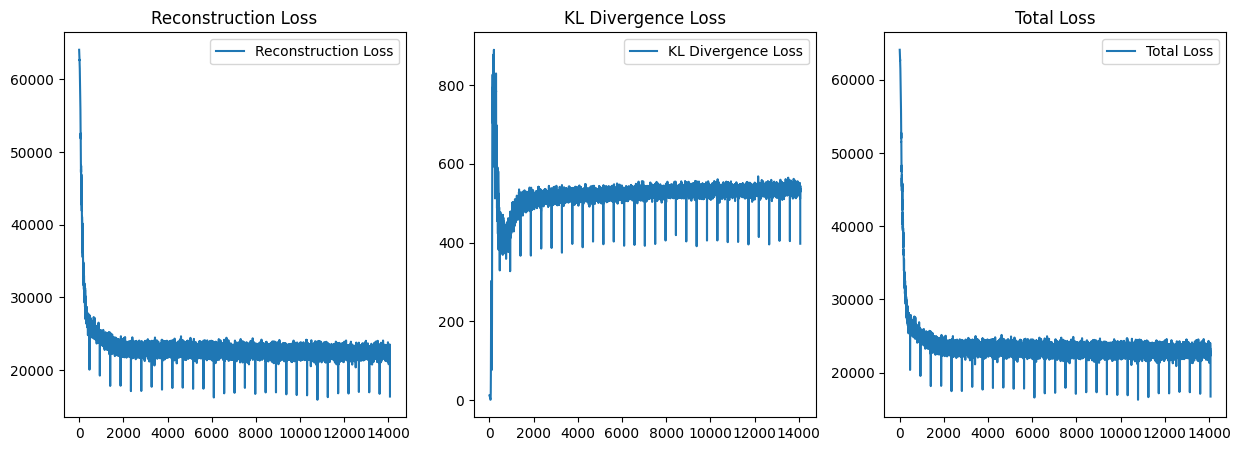

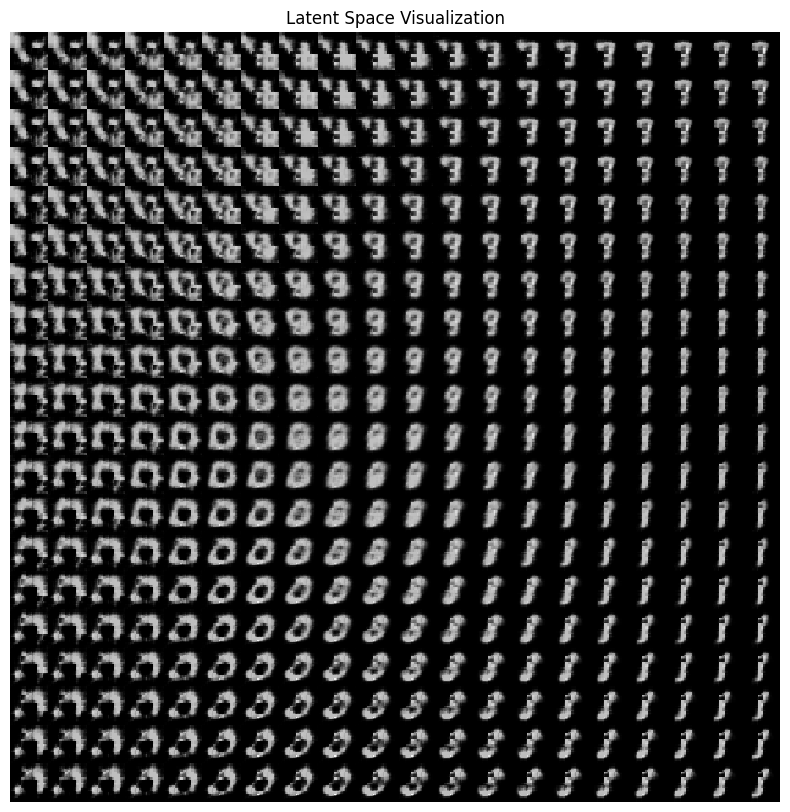

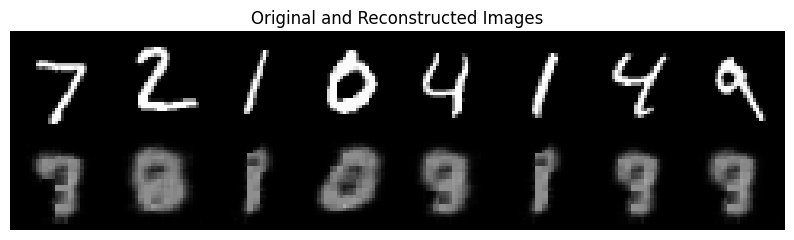

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Define the encoder
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=4, stride=2, padding=0)
        self.conv2 = nn.Conv2d(8, 6, kernel_size=3, stride=2, padding=0)
        self.conv3 = nn.Conv2d(6, 4, kernel_size=3, stride=3, padding=0)
        self.conv4 = nn.Conv2d(4, 4, kernel_size=2, stride=1, padding=0)
        self.fc_mu = nn.Linear(4*1*1, 2)
        self.fc_logvar = nn.Linear(4*1*1, 2)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# Define the decoder
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(2, 4*1*1)
        self.deconv1 = nn.ConvTranspose2d(4, 4, kernel_size=2, stride=1, padding=0)
        self.deconv2 = nn.ConvTranspose2d(4, 6, kernel_size=3, stride=3, padding=0)
        self.deconv3 = nn.ConvTranspose2d(6, 8, kernel_size=3, stride=2, padding=0)
        self.deconv4 = nn.ConvTranspose2d(8, 1, kernel_size=4, stride=2, padding=0)

    def forward(self, z):
        z = self.fc(z)
        z = z.view(z.size(0), 4, 1, 1)
        z = torch.relu(self.deconv1(z))
        z = torch.relu(self.deconv2(z))
        z = torch.relu(self.deconv3(z))
        z = torch.sigmoid(self.deconv4(z))
        return z

# VAE model
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

# Loss function
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE, KLD

# Data loading and preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to range [0, 1]
])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Model, optimizer and training
vae = VAE()
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Tracking losses
recon_losses = []
kl_losses = []
total_losses = []

def train(epoch):
    vae.train()
    train_loss = 0
    train_recon_loss = 0
    train_kl_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()

        # Ensure data is in the range [0, 1]
        data = (data + 1) / 2

        recon_batch, mu, logvar = vae(data)

        recon_loss, kl_loss = loss_function(recon_batch, data, mu, logvar)
        loss = recon_loss + kl_loss

        loss.backward()
        optimizer.step()

        # Track losses per iteration
        recon_losses.append(recon_loss.item())
        kl_losses.append(kl_loss.item())
        total_losses.append(loss.item())

    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# Training with adjustable learning rate
num_epochs = 30
for epoch in range(1, num_epochs + 1):
    train(epoch)
    if epoch == 5:  # Example of adjusting learning rate
        for param_group in optimizer.param_groups:
            param_group['lr'] = 1e-4

# Plot the training losses over iterations
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(recon_losses, label='Reconstruction Loss')
plt.title('Reconstruction Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(kl_losses, label='KL Divergence Loss')
plt.title('KL Divergence Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(total_losses, label='Total Loss')
plt.title('Total Loss')
plt.legend()

plt.show()

# Visualization of the latent space and test data performance
vae.eval()

# Latent space visualization
with torch.no_grad():
    n = 20
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)
    figure = np.zeros((28 * n, 28 * n))

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32)
            x_decoded = vae.decoder(z_sample)
            digit = x_decoded[0].numpy().reshape(28, 28)
            figure[i * 28: (i + 1) * 28,
                   j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray', interpolation='nearest')
plt.title('Latent Space Visualization')
plt.axis('off')
plt.show()

# Test data reconstruction
with torch.no_grad():
    data, _ = next(iter(test_loader))

    # Ensure data is in the range [0, 1]
    data = (data + 1) / 2

    recon_data, _, _ = vae(data)

    n = min(data.size(0), 8)
    comparison = torch.cat([data[:n], recon_data[:n]])

    grid = np.transpose(torchvision.utils.make_grid(comparison, nrow=n, padding=2, normalize=True).numpy(), (1, 2, 0))

plt.figure(figsize=(10, 5))
plt.imshow(grid, cmap='gray', interpolation='nearest')
plt.title('Original and Reconstructed Images')
plt.axis('off')
plt.show()


# VAE Added neurons no noise

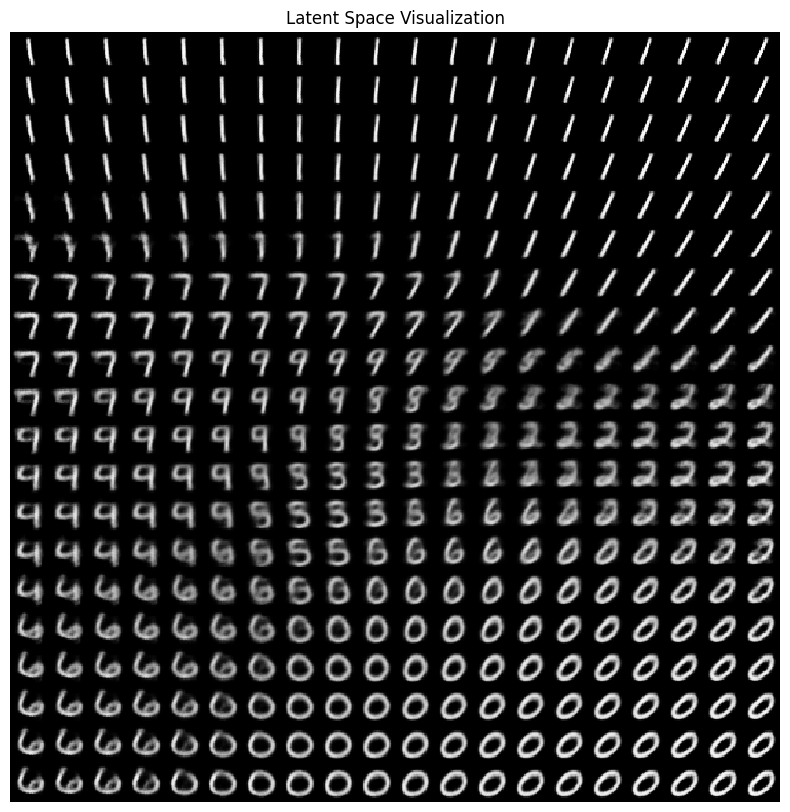

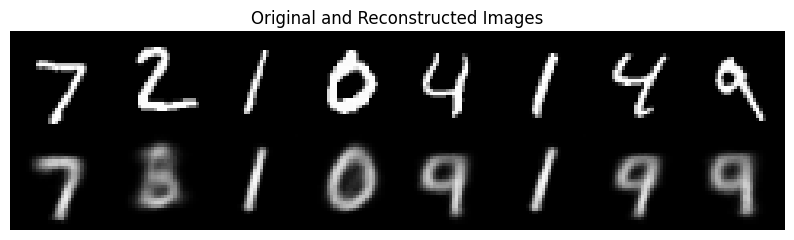

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the encoder
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)  # 28 -> 14
        self.dropout1 = nn.Dropout(0.1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 14 -> 7
        self.dropout2 = nn.Dropout(0.1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)  # 7 -> 4
        self.dropout3 = nn.Dropout(0.1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=1, padding=1)  # 4 -> 2
        self.dropout4 = nn.Dropout(0.1)
        self.fc_mu = nn.Linear(256 * 2 * 2, 2)
        self.fc_logvar = nn.Linear(256 * 2 * 2, 2)
        self.classifier = nn.Linear(2, 10)  # Classifier for digit classification

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.dropout1(x)
        x = torch.relu(self.conv2(x))
        x = self.dropout2(x)
        x = torch.relu(self.conv3(x))
        x = self.dropout3(x)
        x = torch.relu(self.conv4(x))
        x = self.dropout4(x)
        x = x.view(x.size(0), -1)
        # print(f'Encoder output shape: {x.shape}')
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar, self.classifier(mu)

# Define the decoder
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(2, 256 * 2 * 2)
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)  # 2 -> 4
        self.dropout1 = nn.Dropout(0.1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)  # 4 -> 8
        self.dropout2 = nn.Dropout(0.1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 8 -> 16
        self.dropout3 = nn.Dropout(0.1)
        self.deconv4 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)  # 16 -> 32

    def forward(self, z):
        z = self.fc(z)
        z = z.view(z.size(0), 256, 2, 2)
        z = torch.relu(self.deconv1(z))
        z = self.dropout1(z)
        z = torch.relu(self.deconv2(z))
        z = self.dropout2(z)
        z = torch.relu(self.deconv3(z))
        z = self.dropout3(z)
        z = torch.sigmoid(self.deconv4(z))
        z = z[:, :, 2:30, 2:30]  # Crop to 28x28
        return z

# Define the VAE
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar, _ = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

# Loss functions
def reconstruction_loss(recon_x, x):
    return nn.functional.mse_loss(recon_x, x, reduction='sum')

def kl_divergence(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

def classification_loss(pred, target):
    return nn.functional.cross_entropy(pred, target)

# Data loading and preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Model, optimizer and training
vae = VAE().to(device)
classifier_params = list(vae.encoder.fc_mu.parameters()) + list(vae.encoder.fc_logvar.parameters()) + list(vae.encoder.classifier.parameters())
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
optimizer_classifier = optim.Adam(classifier_params, lr=1e-3)

# Training classification loss
def train_classification(epoch):
    vae.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer_classifier.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        data = (data + 1) / 2
        data, target = data.to(device), target.to(device)

        _, _, pred = vae.encoder(data)
        loss = classification_loss(pred, target)
        loss.backward()
        optimizer_classifier.step()

# Training reconstruction loss
def train_reconstruction(epoch):
    vae.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        data = (data + 1) / 2
        data = data.to(device)

        recon_batch, mu, logvar = vae(data)
        recon_loss = reconstruction_loss(recon_batch, data)
        kl_loss = kl_divergence(mu, logvar)
        loss = recon_loss + kl_loss
        loss.backward()
        optimizer.step()

# Joint training
def joint_training(epoch, alpha=0.5):
    vae.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        data = (data + 1) / 2
        data, target = data.to(device), target.to(device)

        recon_batch, mu, logvar = vae(data)
        _, _, pred = vae.encoder(data)

        recon_loss = reconstruction_loss(recon_batch, data)
        kl_loss = kl_divergence(mu, logvar)
        class_loss = classification_loss(pred, target)

        loss = alpha * class_loss + (1 - alpha) * (recon_loss + kl_loss)
        loss.backward()
        optimizer.step()

# Training and evaluation loop
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    if epoch <= 3:
        train_classification(epoch)
    elif 3 < epoch <= 6:
        train_reconstruction(epoch)
    else:
        joint_training(epoch, alpha=0.5)

# Visualization of the latent space and test data performance
vae.eval()

# Latent space visualization
with torch.no_grad():
    n = 20
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)
    figure = np.zeros((28 * n, 28 * n))

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = vae.decoder(z_sample)
            digit = x_decoded[0].cpu().numpy().reshape(28, 28)
            figure[i * 28: (i + 1) * 28,
                   j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray', interpolation='nearest')
plt.title('Latent Space Visualization')
plt.axis('off')
plt.show()

# Test data reconstruction
with torch.no_grad():
    data, _ = next(iter(test_loader))

    # Normalize data to [0, 1] and move to GPU
    data = (data + 1) / 2
    data = data.to(device)

    recon_data, _, _ = vae(data)

    n = min(data.size(0), 8)
    comparison = torch.cat([data[:n], recon_data[:n]]).cpu()

    grid = np.transpose(torchvision.utils.make_grid(comparison, nrow=n, padding=2, normalize=True).numpy(), (1, 2, 0))

plt.figure(figsize=(10, 5))
plt.imshow(grid, cmap='gray', interpolation='nearest')
plt.title('Original and Reconstructed Images')
plt.axis('off')
plt.show()


# VAE Added neurons no noise

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 48624799.85it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 1832834.44it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 3143841.36it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 2895217.14it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



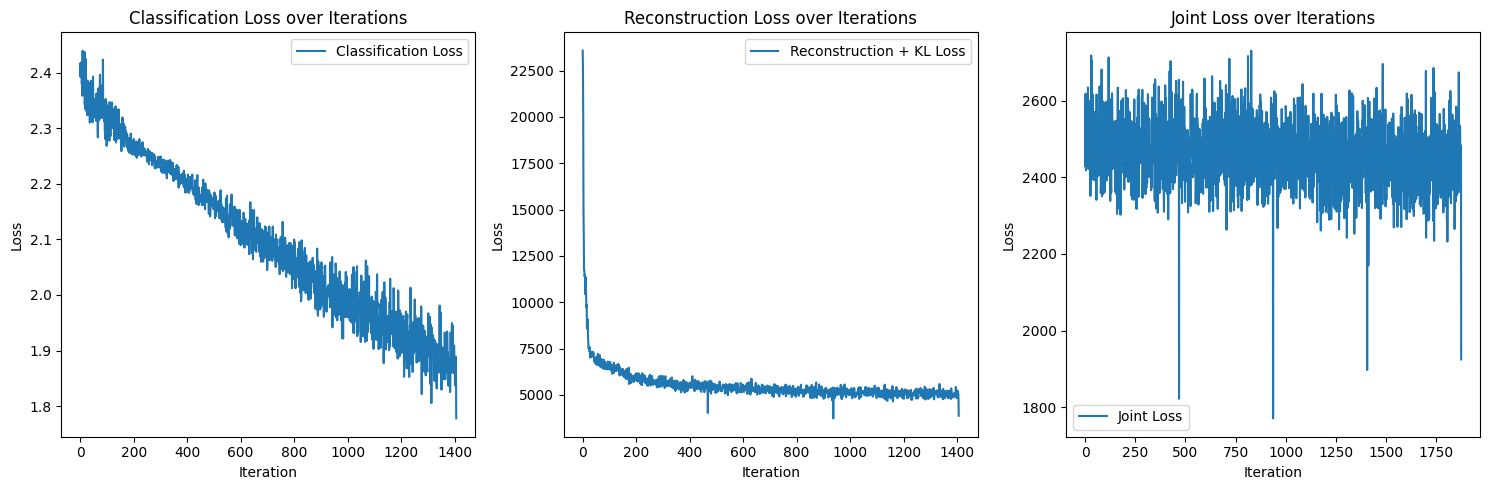

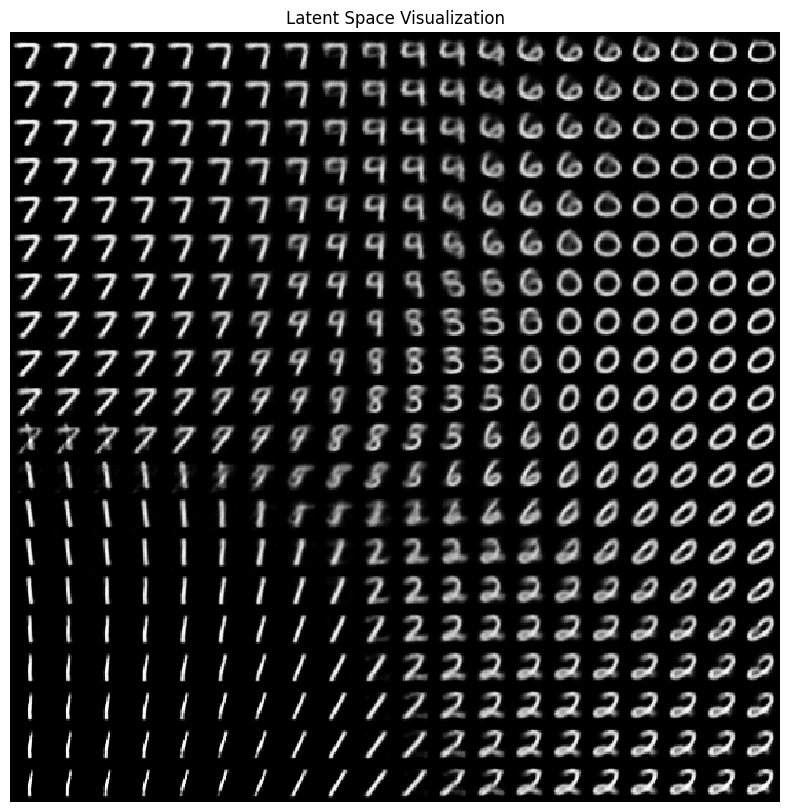

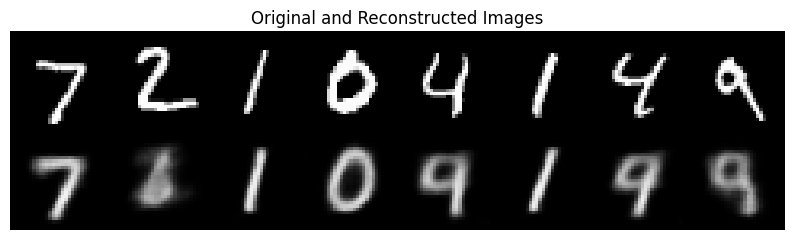

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the encoder
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)  # 28 -> 14
        self.dropout1 = nn.Dropout(0.1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 14 -> 7
        self.dropout2 = nn.Dropout(0.1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)  # 7 -> 4
        self.dropout3 = nn.Dropout(0.1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=1, padding=1)  # 4 -> 2
        self.dropout4 = nn.Dropout(0.1)
        self.fc_mu = nn.Linear(256 * 2 * 2, 2)
        self.fc_logvar = nn.Linear(256 * 2 * 2, 2)
        self.classifier = nn.Linear(2, 10)  # Classifier for digit classification

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.dropout1(x)
        x = torch.relu(self.conv2(x))
        x = self.dropout2(x)
        x = torch.relu(self.conv3(x))
        x = self.dropout3(x)
        x = torch.relu(self.conv4(x))
        x = self.dropout4(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar, self.classifier(mu)

# Define the decoder
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(2, 256 * 2 * 2)
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)  # 2 -> 4
        self.dropout1 = nn.Dropout(0.1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)  # 4 -> 8
        self.dropout2 = nn.Dropout(0.1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 8 -> 16
        self.dropout3 = nn.Dropout(0.1)
        self.deconv4 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)  # 16 -> 32

    def forward(self, z):
        z = self.fc(z)
        z = z.view(z.size(0), 256, 2, 2)
        z = torch.relu(self.deconv1(z))
        z = self.dropout1(z)
        z = torch.relu(self.deconv2(z))
        z = self.dropout2(z)
        z = torch.relu(self.deconv3(z))
        z = self.dropout3(z)
        z = torch.sigmoid(self.deconv4(z))
        z = z[:, :, 2:30, 2:30]  # Crop to 28x28
        return z

# Define the VAE
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar, _ = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

# Loss functions
def reconstruction_loss(recon_x, x):
    return nn.functional.mse_loss(recon_x, x, reduction='sum')

def kl_divergence(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

def classification_loss(pred, target):
    return nn.functional.cross_entropy(pred, target)

# Data loading and preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Model, optimizer and training
vae = VAE().to(device)
classifier_params = list(vae.encoder.fc_mu.parameters()) + list(vae.encoder.fc_logvar.parameters()) + list(vae.encoder.classifier.parameters())
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
optimizer_classifier = optim.Adam(classifier_params, lr=1e-3)

# Track loss over iterations
classification_losses = []
reconstruction_losses = []
joint_losses = []

# Training classification loss
def train_classification(epoch):
    vae.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer_classifier.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        data = (data + 1) / 2
        data, target = data.to(device), target.to(device)

        _, _, pred = vae.encoder(data)
        loss = classification_loss(pred, target)
        loss.backward()
        optimizer_classifier.step()

        classification_losses.append(loss.item())

# Training reconstruction loss
def train_reconstruction(epoch):
    vae.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        data = (data + 1) / 2
        data = data.to(device)

        recon_batch, mu, logvar = vae(data)
        recon_loss = reconstruction_loss(recon_batch, data)
        kl_loss = kl_divergence(mu, logvar)
        loss = recon_loss + kl_loss
        loss.backward()
        optimizer.step()

        reconstruction_losses.append(loss.item())

# Joint training
def joint_training(epoch, alpha=0.5):
    vae.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        data = (data + 1) / 2
        data, target = data.to(device), target.to(device)

        recon_batch, mu, logvar = vae(data)
        _, _, pred = vae.encoder(data)

        recon_loss = reconstruction_loss(recon_batch, data)
        kl_loss = kl_divergence(mu, logvar)
        class_loss = classification_loss(pred, target)

        loss = alpha * class_loss + (1 - alpha) * (recon_loss + kl_loss)
        loss.backward()
        optimizer.step()

        joint_losses.append(loss.item())

# Training and evaluation loop
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    if epoch <= 3:
        train_classification(epoch)
    elif 3 < epoch <= 6:
        train_reconstruction(epoch)
    else:
        joint_training(epoch, alpha=0.5)

# Plot the losses
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(classification_losses, label='Classification Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Classification Loss over Iterations')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(reconstruction_losses, label='Reconstruction + KL Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Reconstruction Loss over Iterations')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(joint_losses, label='Joint Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Joint Loss over Iterations')
plt.legend()

plt.tight_layout()
plt.show()

# Visualization of the latent space and test data performance
vae.eval()

# Latent space visualization
with torch.no_grad():
    n = 20
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)
    figure = np.zeros((28 * n, 28 * n))

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = vae.decoder(z_sample)
            digit = x_decoded[0].cpu().numpy().reshape(28, 28)
            figure[i * 28: (i + 1) * 28,
                   j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray', interpolation='nearest')
plt.title('Latent Space Visualization')
plt.axis('off')
plt.show()

# Test data reconstruction
with torch.no_grad():
    data, _ = next(iter(test_loader))

    # Normalize data to [0, 1] and move to GPU
    data = (data + 1) / 2
    data = data.to(device)

    recon_data, _, _ = vae(data)

    n = min(data.size(0), 8)
    comparison = torch.cat([data[:n], recon_data[:n]]).cpu()

    grid = np.transpose(torchvision.utils.make_grid(comparison, nrow=n, padding=2, normalize=True).numpy(), (1, 2, 0))

plt.figure(figsize=(10, 5))
plt.imshow(grid, cmap='gray', interpolation='nearest')
plt.title('Original and Reconstructed Images')
plt.axis('off')
plt.show()


## VAE Added neurons with Noise

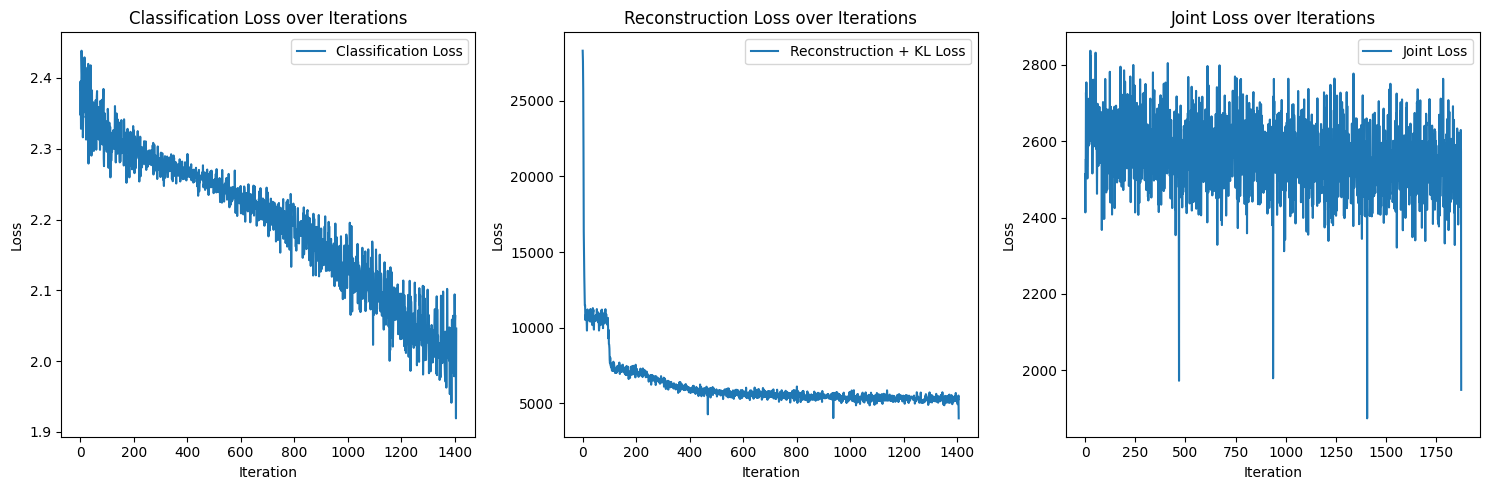

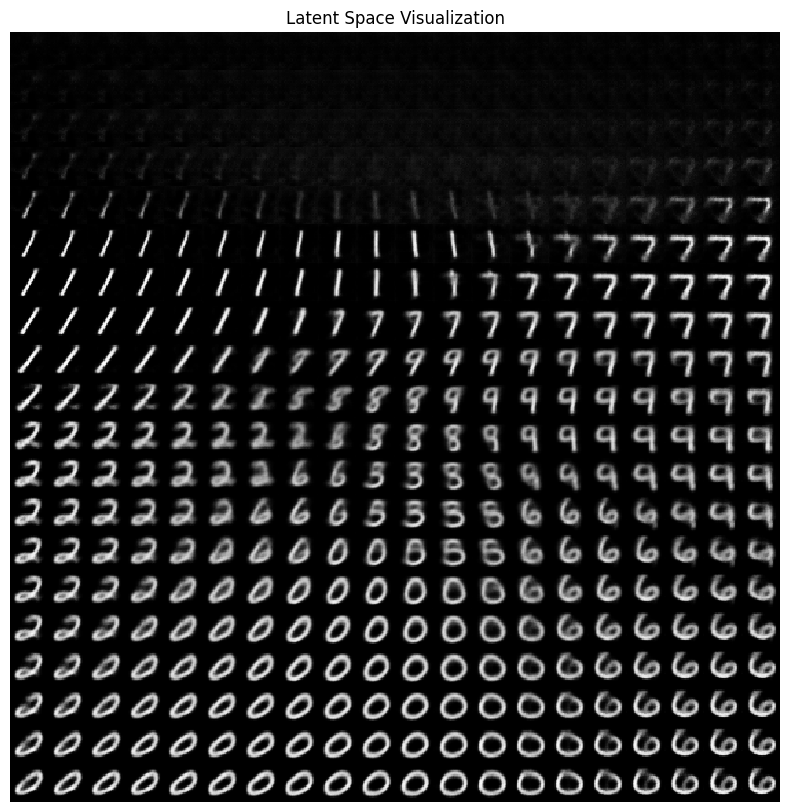

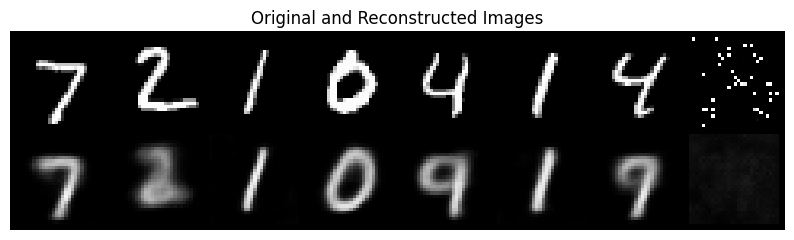

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Custom transform to add salt-and-pepper noise
class SaltAndPepperNoise(object):
    def __init__(self, prob=0.1):
        self.prob = prob

    def __call__(self, img):
        if torch.rand(1).item() < self.prob:
            img = np.array(img)
            salt_pepper_noise = np.random.choice([0, 1, 255], img.shape, p=[1 - self.prob, self.prob / 2, self.prob / 2])
            img = np.where(salt_pepper_noise == 255, 1.0, img)  # Salt noise
            img = np.where(salt_pepper_noise == 0, 0.0, img)   # Pepper noise
            img = torch.from_numpy(img).float()
        return img

# Define the encoder
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)  # 28 -> 14
        self.dropout1 = nn.Dropout(0.1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 14 -> 7
        self.dropout2 = nn.Dropout(0.1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)  # 7 -> 4
        self.dropout3 = nn.Dropout(0.1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=1, padding=1)  # 4 -> 2
        self.dropout4 = nn.Dropout(0.1)
        self.fc_mu = nn.Linear(256 * 2 * 2, 2)
        self.fc_logvar = nn.Linear(256 * 2 * 2, 2)
        self.classifier = nn.Linear(2, 10)  # Classifier for digit classification

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.dropout1(x)
        x = torch.relu(self.conv2(x))
        x = self.dropout2(x)
        x = torch.relu(self.conv3(x))
        x = self.dropout3(x)
        x = torch.relu(self.conv4(x))
        x = self.dropout4(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar, self.classifier(mu)

# Define the decoder
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(2, 256 * 2 * 2)
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)  # 2 -> 4
        self.dropout1 = nn.Dropout(0.1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)  # 4 -> 8
        self.dropout2 = nn.Dropout(0.1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 8 -> 16
        self.dropout3 = nn.Dropout(0.1)
        self.deconv4 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)  # 16 -> 32

    def forward(self, z):
        z = self.fc(z)
        z = z.view(z.size(0), 256, 2, 2)
        z = torch.relu(self.deconv1(z))
        z = self.dropout1(z)
        z = torch.relu(self.deconv2(z))
        z = self.dropout2(z)
        z = torch.relu(self.deconv3(z))
        z = self.dropout3(z)
        z = torch.sigmoid(self.deconv4(z))
        z = z[:, :, 2:30, 2:30]  # Crop to 28x28
        return z

# Define the VAE
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar, _ = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

# Loss functions
def reconstruction_loss(recon_x, x):
    return nn.functional.mse_loss(recon_x, x, reduction='sum')

def kl_divergence(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

def classification_loss(pred, target):
    return nn.functional.cross_entropy(pred, target)

# Data loading and preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    SaltAndPepperNoise(prob=0.1),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Model, optimizer and training
vae = VAE().to(device)
classifier_params = list(vae.encoder.fc_mu.parameters()) + list(vae.encoder.fc_logvar.parameters()) + list(vae.encoder.classifier.parameters())
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
optimizer_classifier = optim.Adam(classifier_params, lr=1e-3)

# Track loss over iterations
classification_losses = []
reconstruction_losses = []
joint_losses = []

# Training classification loss
def train_classification(epoch):
    vae.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer_classifier.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        data = (data + 1) / 2
        data, target = data.to(device), target.to(device)

        _, _, pred = vae.encoder(data)
        loss = classification_loss(pred, target)
        loss.backward()
        optimizer_classifier.step()

        classification_losses.append(loss.item())

# Training reconstruction loss
def train_reconstruction(epoch):
    vae.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        optimizer.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        data = (data + 1) / 2
        data = data.to(device)

        recon_batch, mu, logvar = vae(data)
        recon_loss = reconstruction_loss(recon_batch, data)
        kl_loss = kl_divergence(mu, logvar)
        loss = recon_loss + kl_loss
        loss.backward()
        optimizer.step()

        reconstruction_losses.append(loss.item())

# Joint training
def joint_training(epoch, alpha=0.5):
    vae.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        data = (data + 1) / 2
        data, target = data.to(device), target.to(device)

        recon_batch, mu, logvar = vae(data)
        _, _, pred = vae.encoder(data)

        recon_loss = reconstruction_loss(recon_batch, data)
        kl_loss = kl_divergence(mu, logvar)
        class_loss = classification_loss(pred, target)

        loss = alpha * class_loss + (1 - alpha) * (recon_loss + kl_loss)
        loss.backward()
        optimizer.step()

        joint_losses.append(loss.item())

# Training and evaluation loop
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    if epoch <= 3:
        train_classification(epoch)
    elif 3 < epoch <= 6:
        train_reconstruction(epoch)
    else:
        joint_training(epoch, alpha=0.5)

# Plot the losses
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(classification_losses, label='Classification Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Classification Loss over Iterations')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(reconstruction_losses, label='Reconstruction + KL Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Reconstruction Loss over Iterations')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(joint_losses, label='Joint Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Joint Loss over Iterations')
plt.legend()

plt.tight_layout()
plt.show()

# Visualization of the latent space and test data performance
vae.eval()

# Latent space visualization
with torch.no_grad():
    n = 20
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)
    figure = np.zeros((28 * n, 28 * n))

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = vae.decoder(z_sample)
            digit = x_decoded[0].cpu().numpy().reshape(28, 28)
            figure[i * 28: (i + 1) * 28,
                   j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray', interpolation='nearest')
plt.title('Latent Space Visualization')
plt.axis('off')
plt.show()

# Test data reconstruction
with torch.no_grad():
    data, _ = next(iter(test_loader))

    # Normalize data to [0, 1] and move to GPU
    data = (data + 1) / 2
    data = data.to(device)

    recon_data, _, _ = vae(data)

    n = min(data.size(0), 8)
    comparison = torch.cat([data[:n], recon_data[:n]]).cpu()

    grid = np.transpose(torchvision.utils.make_grid(comparison, nrow=n, padding=2, normalize=True).numpy(), (1, 2, 0))

plt.figure(figsize=(10, 5))
plt.imshow(grid, cmap='gray', interpolation='nearest')
plt.title('Original and Reconstructed Images')
plt.axis('off')
plt.show()


# Noise added

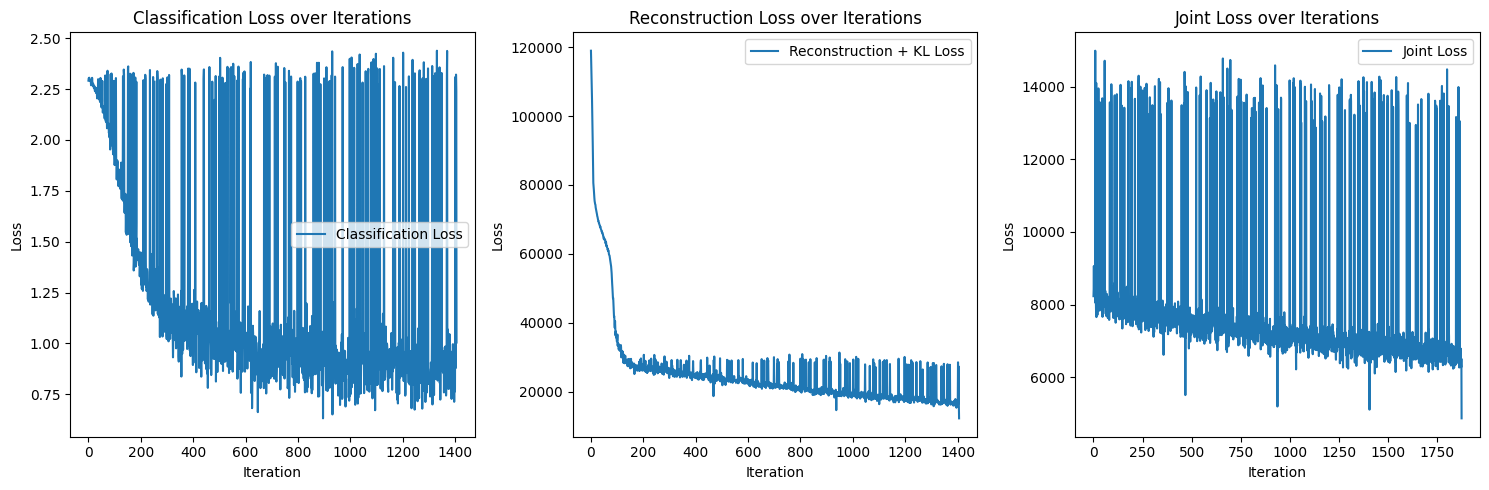

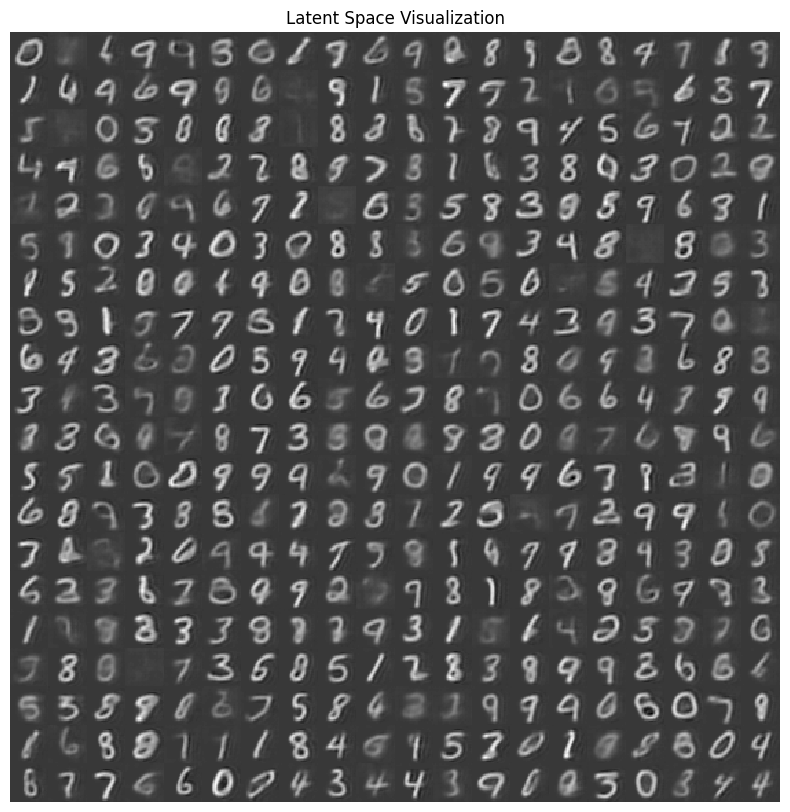

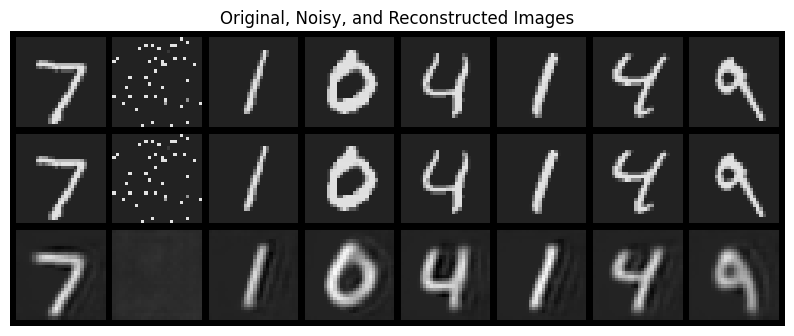

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Custom transform to add salt-and-pepper noise
class SaltAndPepperNoise(object):
    def __init__(self, prob=0.1):
        self.prob = prob

    def __call__(self, img):
        if torch.rand(1).item() < self.prob:
            img = np.array(img)
            salt_pepper_noise = np.random.choice([0, 1, 255], img.shape, p=[1 - self.prob, self.prob / 2, self.prob / 2])
            img = np.where(salt_pepper_noise == 255, 1.0, img)  # Salt noise
            img = np.where(salt_pepper_noise == 0, 0.0, img)   # Pepper noise
            img = torch.from_numpy(img).float()
        return img

# Define the encoder
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)  # 28 -> 14
        self.dropout1 = nn.Dropout(0.1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 14 -> 7
        self.dropout2 = nn.Dropout(0.1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)  # 7 -> 4
        self.dropout3 = nn.Dropout(0.1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=1, padding=1)  # 4 -> 2
        self.dropout4 = nn.Dropout(0.1)
        self.fc_mu = nn.Linear(256 * 2 * 2, 128)
        self.fc_logvar = nn.Linear(256 * 2 * 2, 128)
        self.classifier = nn.Linear(128, 10)  # Classifier for digit classification

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.dropout1(x)
        x = torch.relu(self.conv2(x))
        x = self.dropout2(x)
        x = torch.relu(self.conv3(x))
        x = self.dropout3(x)
        x = torch.relu(self.conv4(x))
        x = self.dropout4(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar, self.classifier(mu)

# Define the decoder
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(128, 256 * 2 * 2)
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)  # 2 -> 4
        self.dropout1 = nn.Dropout(0.1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)  # 4 -> 8
        self.dropout2 = nn.Dropout(0.1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 8 -> 16
        self.dropout3 = nn.Dropout(0.1)
        self.deconv4 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)  # 16 -> 32
        self.crop = nn.Conv2d(1, 1, kernel_size=5)  # to crop the 32x32 to 28x28

    def forward(self, z):
        z = self.fc(z)
        z = z.view(z.size(0), 256, 2, 2)
        z = torch.relu(self.deconv1(z))
        z = self.dropout1(z)
        z = torch.relu(self.deconv2(z))
        z = self.dropout2(z)
        z = torch.relu(self.deconv3(z))
        z = self.dropout3(z)
        z = torch.sigmoid(self.deconv4(z))
        z = self.crop(z)  # Crop to 28x28
        return z

# Define the VAE
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar, _ = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

# Loss functions
def reconstruction_loss(recon_x, x):
    return nn.functional.mse_loss(recon_x, x, reduction='sum')

def kl_divergence(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

def classification_loss(pred, target):
    return nn.functional.cross_entropy(pred, target)

# Data loading and preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    SaltAndPepperNoise(prob=0.1),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Model, optimizer and training
vae = VAE().to(device)
classifier_params = list(vae.encoder.fc_mu.parameters()) + list(vae.encoder.fc_logvar.parameters()) + list(vae.encoder.classifier.parameters())
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
optimizer_classifier = optim.Adam(classifier_params, lr=1e-3)

# Track loss over iterations
classification_losses = []
reconstruction_losses = []
joint_losses = []

# Training classification loss
def train_classification(epoch):
    vae.train()
    for batch_idx, (clean_data, target) in enumerate(train_loader):
        noisy_data = SaltAndPepperNoise(prob=0.1)(clean_data)

        optimizer_classifier.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        clean_data, noisy_data, target = clean_data.to(device), noisy_data.to(device), target.to(device)

        _, _, pred = vae.encoder(noisy_data)
        loss = classification_loss(pred, target)
        loss.backward()
        optimizer_classifier.step()

        classification_losses.append(loss.item())

# Training reconstruction loss
def train_reconstruction(epoch):
    vae.train()
    for batch_idx, (clean_data, _) in enumerate(train_loader):
        noisy_data = SaltAndPepperNoise(prob=0.1)(clean_data)

        optimizer.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        clean_data, noisy_data = clean_data.to(device), noisy_data.to(device)

        recon_batch, mu, logvar = vae(noisy_data)
        recon_loss = reconstruction_loss(recon_batch, clean_data)
        kl_loss = kl_divergence(mu, logvar)
        loss = recon_loss + kl_loss
        loss.backward()
        optimizer.step()

        reconstruction_losses.append(loss.item())

# Joint training
def joint_training(epoch, alpha=0.5):
    vae.train()
    for batch_idx, (clean_data, target) in enumerate(train_loader):
        noisy_data = SaltAndPepperNoise(prob=0.1)(clean_data)

        optimizer.zero_grad()

        # Normalize data to [0, 1] and move to GPU
        clean_data, noisy_data, target = clean_data.to(device), noisy_data.to(device), target.to(device)

        recon_batch, mu, logvar = vae(noisy_data)
        _, _, pred = vae.encoder(noisy_data)

        recon_loss = reconstruction_loss(recon_batch, clean_data)
        kl_loss = kl_divergence(mu, logvar)
        class_loss = classification_loss(pred, target)

        loss = alpha * class_loss + (1 - alpha) * (recon_loss + kl_loss)
        loss.backward()
        optimizer.step()

        joint_losses.append(loss.item())

# Training and evaluation loop
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    if epoch <= 3:
        train_classification(epoch)
    elif 3 < epoch <= 6:
        train_reconstruction(epoch)
    else:
        joint_training(epoch, alpha=0.5)

# Plot the losses
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(classification_losses, label='Classification Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Classification Loss over Iterations')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(reconstruction_losses, label='Reconstruction + KL Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Reconstruction Loss over Iterations')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(joint_losses, label='Joint Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Joint Loss over Iterations')
plt.legend()

plt.tight_layout()
plt.show()

# Visualization of the latent space and test data performance
vae.eval()

# Latent space visualization
with torch.no_grad():
    # Generate random samples in the latent space
    n = 20
    latent_samples = torch.randn(n * n, 128).to(device)  # Generate samples from the normal distribution
    figure = np.zeros((28 * n, 28 * n))

    for i in range(n):
        for j in range(n):
            z_sample = latent_samples[i * n + j].unsqueeze(0)
            x_decoded = vae.decoder(z_sample)
            digit = x_decoded[0].cpu().numpy().reshape(28, 28)
            figure[i * 28: (i + 1) * 28,
                   j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray', interpolation='nearest')
plt.title('Latent Space Visualization')
plt.axis('off')
plt.show()

# Test data reconstruction
with torch.no_grad():
    data, _ = next(iter(test_loader))

    noisy_data = SaltAndPepperNoise(prob=0.1)(data)

    # Normalize data to [0, 1] and move to GPU
    data, noisy_data = data.to(device), noisy_data.to(device)

    recon_data, _, _ = vae(noisy_data)

    n = min(data.size(0), 8)
    comparison = torch.cat([data[:n], noisy_data[:n], recon_data[:n]]).cpu()

    grid = np.transpose(torchvision.utils.make_grid(comparison, nrow=n, padding=2, normalize=True).numpy(), (1, 2, 0))

plt.figure(figsize=(10, 5))
plt.imshow(grid, cmap='gray', interpolation='nearest')
plt.title('Original, Noisy, and Reconstructed Images')
plt.axis('off')
plt.show()
